<a href="https://colab.research.google.com/github/mario-vipin/investigating-Netflix-movies-from-1997/blob/main/i%3DInvestigating-Netflix-movies-1990's.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Shape: (4812, 11)
  show_id     type  title           director  \
0      s2    Movie   7:19  Jorge Michel Grau   
1      s3    Movie  23:59       Gilbert Chan   
2      s4    Movie      9        Shane Acker   
3      s5    Movie     21     Robert Luketic   
4      s6  TV Show     46        Serdar Akar   

                                                cast        country  \
0  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
1  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
2  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
3  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   
4  Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...         Turkey   

          date_added  release_year  duration  \
0  December 23, 2016          2016        93   
1  December 20, 2018          2011        78   
2  November 16, 2017          2009        80   
3    January 1, 2020          2008       123   
4       July 1, 2017      

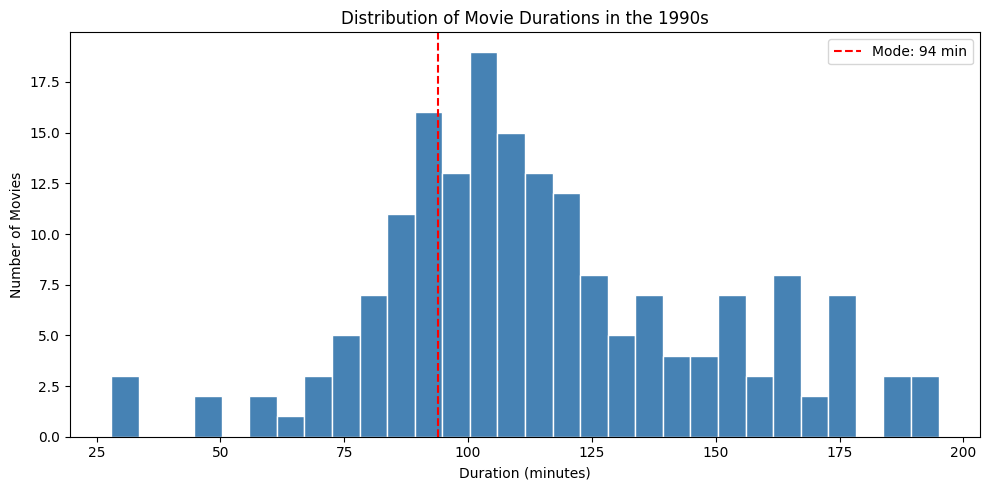

Number of short (<90 min) Action movies in the 1990s: 7

========== FINAL ANSWERS ==========
duration         = 94
short_movie_count = 7


In [2]:
# ============================================================
# Netflix 1990s Movie Analysis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Load the data
# ------------------------------------------------------------
netflix_df = pd.read_csv("netflix_data.csv")
print("Shape:", netflix_df.shape)
print(netflix_df.head())

# ------------------------------------------------------------
# 2. Filter: Movies only, released in the 1990s
# ------------------------------------------------------------
movies_90s = netflix_df[
    (netflix_df["type"] == "Movie") &
    (netflix_df["release_year"] >= 1990) &
    (netflix_df["release_year"] < 2000)
]

print(f"\nTotal 1990s movies: {len(movies_90s)}")

# ------------------------------------------------------------
# 3. Most frequent movie duration in the 1990s
# ------------------------------------------------------------
duration = int(movies_90s["duration"].mode()[0])
print(f"\nMost frequent movie duration in the 1990s: {duration} minutes")

# Plot the distribution
plt.figure(figsize=(10, 5))
plt.hist(movies_90s["duration"], bins=30, color="steelblue", edgecolor="white")
plt.axvline(duration, color="red", linestyle="--", label=f"Mode: {duration} min")
plt.title("Distribution of Movie Durations in the 1990s")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Count short Action movies (< 90 min) from the 1990s
# ------------------------------------------------------------
short_action_90s = movies_90s[
    (movies_90s["genre"] == "Action") &
    (movies_90s["duration"] < 90)
]

short_movie_count = len(short_action_90s)
print(f"Number of short (<90 min) Action movies in the 1990s: {short_movie_count}")

# ------------------------------------------------------------
# 5. Final answers
# ------------------------------------------------------------
print("\n========== FINAL ANSWERS ==========")
print(f"duration         = {duration}")
print(f"short_movie_count = {short_movie_count}")